<a href="https://colab.research.google.com/github/1kilele/Data-science-/blob/main/Cryptocurrency_analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import yfinance as yf

print("ESTABLISHING UPLINK TO FINANCIAL MARKETS...")

# 1. Target the Asset (You can change this to 'ETH-USD' or 'AAPL' later)
ticker_symbol = "BTC-USD"
crypto_asset = yf.Ticker(ticker_symbol)

# 2. Extract the historical data (1 year of daily data)
crypto_df = crypto_asset.history(period="1y")

# 3. Clean up the timezone data so it's easier to read
crypto_df.index = crypto_df.index.tz_localize(None)

print(f"[{ticker_symbol}] DATA SECURED. ROWS CAPTURED: {len(crypto_df)}")
crypto_df.head()

ESTABLISHING UPLINK TO FINANCIAL MARKETS...
[BTC-USD] DATA SECURED. ROWS CAPTURED: 366


,Open,High,Low,Close,Volume,Dividends,Stock Splits
Date,,,,,,,
2025-05-22,109673.492188,111970.171875,109285.070312,111673.281250,70157575642,0.0,0.0
2025-05-23,111679.359375,111798.906250,106841.304688,107287.796875,67548133399,0.0,0.0
2025-05-24,107278.507812,109454.523438,106895.289062,107791.156250,45903627163,0.0,0.0
2025-05-25,107802.273438,109313.304688,106683.375000,109035.390625,47518041841,0.0,0.0
2025-05-26,109023.781250,110376.882812,108735.640625,109440.367188,45950461571,0.0,0.0


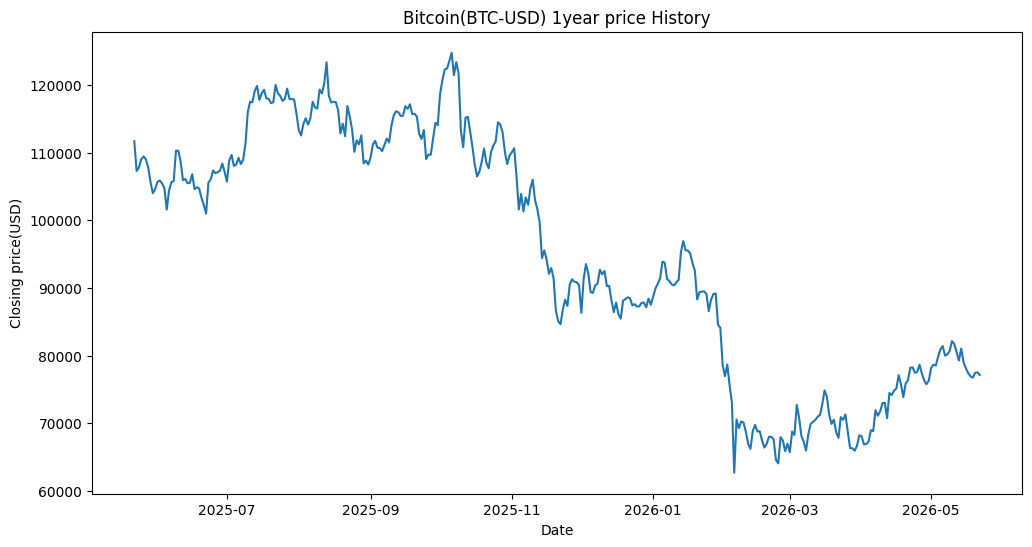

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
plt.plot(crypto_df.index,crypto_df['Close'])
plt.title('Bitcoin(BTC-USD) 1year price History')
plt.xlabel('Date')
plt.ylabel('Closing price(USD)')
plt.show()

In [ ]:

print("CALCULATING 50-DAY MOVING AVERAGE...")

# 1. Feature Engineering: Create the new 50-Day MA column
crypto_df['50_DAY_MA'] = crypto_df['Close']/crypto_df['Close'].rolling(window=50).mean()

# 2. We don't need to see the whole year, just the most recent 5 days
# The .tail() command grabs the very bottom of the dataset (the present day)
latest_trend = crypto_df[['Close', '50_DAY_MA']].tail()

print("\n--- LATEST BITCOIN TREND ---")
print(latest_trend.round(2)) # Rounding to 2 decimals for clean reading

CALCULATING 50-DAY MOVING AVERAGE...

--- LATEST BITCOIN TREND ---
               Close  50_DAY_MA
Date                           
2026-05-18  76954.17       1.02
2026-05-19  76750.91       1.01
2026-05-20  77457.77       1.02
2026-05-21  77539.17       1.02
2026-05-22  77142.03       1.01


In [ ]:
import numpy as np
print("Initializing BACKTESTING ENGINE...")
crypto_df['Signal']=np.where(crypto_df['Close']>crypto_df['50_DAY_MA'],1,0)

#Calculating the Daily profit/loss of Bitcoin itself
crypto_df['Daily_Return']=crypto_df['Close'].pct_change()

#Calculating the Robot's profit/Loss
crypto_df['Strategy_Return']=crypto_df['Signal'].shift(1)*crypto_df['Daily_Return']

backtest_data=crypto_df.dropna().copy()

#The math calculating compound growth
backtest_data['Bitcoin_Growth']=(1+backtest_data['Daily_Return']).cumprod()
backtest_data['Robot_Growth']=(1+backtest_data['Strategy_Return']).cumprod()

final_btc=backtest_data['Bitcoin_Growth'].iloc[-1]
final_robot=backtest_data['Robot_Growth'].iloc[-1]

print("\n---1 year simulation results ---")
print(f"If you just bought and held Bitcoin,your money increased by{final_btc:.2f}x")
print(f"If you used the 50 Day MA bot,your money multiplied by{final_robot:.2f}x")

Initializing BACKTESTING ENGINE...

---1 year simulation results ---
If you just bought and held Bitcoin,your money increased by0.69x
If you used the 50 Day MA bot,your money multiplied by0.67x


In [ ]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score

print("INITIALIZING AI PREDICTIVE ENGINE...")

# 1. THE TARGET: What happens TOMORROW?
# We shift the close price backwards by 1 to literally look into the future for our training answer key
crypto_df['Tomorrow_Close'] = crypto_df['Close'].shift(-1)
crypto_df['Target'] = np.where(crypto_df['Tomorrow_Close'] > crypto_df['Close'], 1, 0)

# 2. THE CLUES: Give the AI some extra context
crypto_df['7_DAY_Trend'] = crypto_df['Close']/crypto_df['Close'].rolling(7).mean()
crypto_df['Volatility'] = crypto_df['Daily_Return'].rolling(7).std()

# Drop NaNs to keep the AI from choking on missing data
ai_data = crypto_df.dropna().copy()

# Define our Clues (X) and Target (y)
features = ['Daily_Return', '50_DAY_MA', '7_DAY_Trend', 'Volatility']
X = ai_data[features]
y = ai_data['Target']

# 3. THE SPLIT: No random shuffling! Train on the past, test on the future.
split_index = int(len(ai_data) * 0.8) # Find the 80% cut-off line
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

# 4. BUILD & TRAIN THE AI (100 Decision Trees voting together)
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)
print("AI TRAINING COMPLETE.")

# 5. THE EXAM: Force the AI to predict the final 20% of the year
predictions = rf_model.predict(X_test)

# 6. GRADE THE EXAM (Using Precision)
# We don't care about general accuracy. In trading, we only care about:
# "When the AI said 'BUY', how often did it actually go up?"
precision = precision_score(y_test, predictions)

print("\n--- AI PREDICTION ENGINE RESULTS ---")
print(f"When the AI predicted the price would go UP tomorrow, it was correct {precision * 100:.2f}% of the time.")

INITIALIZING AI PREDICTIVE ENGINE...
AI TRAINING COMPLETE.

--- AI PREDICTION ENGINE RESULTS ---
When the AI predicted the price would go UP tomorrow, it was correct 50.00% of the time.


In [ ]:
pip install textblob

In [ ]:

# You might need to run this install command in a separate cell first if Colab doesn't have it loaded:
# !pip install textblob

from textblob import TextBlob

print("--- NLP SENTIMENT ANALYSIS ENGINE ---\n")

# 1. The Data: Three different market scenarios
headlines = [
    "SEC approves new Bitcoin ETF, market surges to all-time highs!",
    "Major exchange hacked, millions in crypto stolen, CEO arrested.",
    "Bitcoin price remains flat as traders await interest rate decision."
]

# 2. The Engine: Loop through each headline, analyze it, and print the math
for text in headlines:
    analysis = TextBlob(text)
    score = analysis.sentiment.polarity # Grabs the score from -1.0 to 1.0

    print(f"Headline: '{text}'")
    print(f"NLP Score: {score:.2f}\n")

--- NLP SENTIMENT ANALYSIS ENGINE ---

Headline: 'SEC approves new Bitcoin ETF, market surges to all-time highs!'
NLP Score: 0.04

Headline: 'Major exchange hacked, millions in crypto stolen, CEO arrested.'
NLP Score: 0.06

Headline: 'Bitcoin price remains flat as traders await interest rate decision.'
NLP Score: -0.03

